#Import Libraries and Data

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Twitter Sentiment Analysis - BERT/Twitter_Data.csv")
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [ ]:
df.shape

(162980, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [ ]:
df['category'].value_counts()

,count
category,
1.0,72250
0.0,55213
-1.0,35510


In [ ]:
df.isnull().sum()

,0
clean_text,4
category,7


In [ ]:
df= df.dropna()
df.isna().sum()

,0
clean_text,0
category,0


##Exploratory Data Analysis

/tmp/ipykernel_2206/1086729207.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette = ["#e74c3c", "#95a5a6", "#2ecc71"])


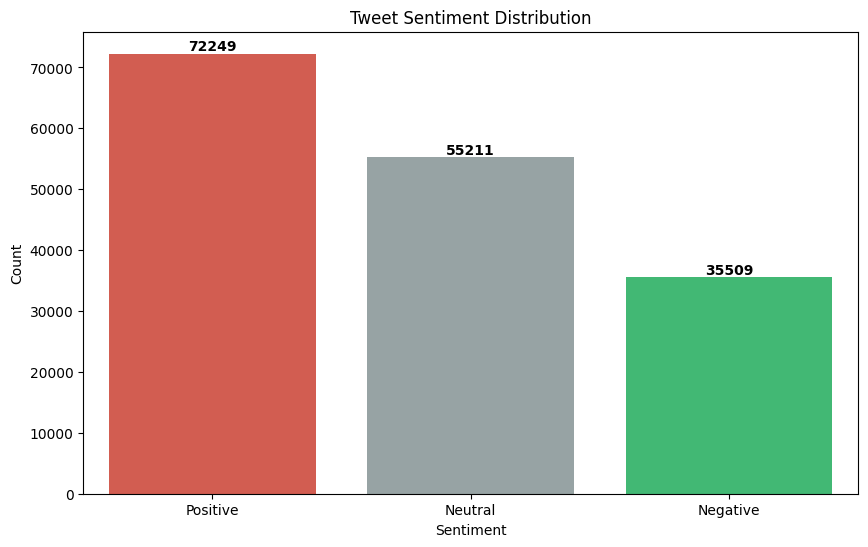

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

label_names = {-1.0: "Negative", 0.0: "Neutral", 1.0: "Positive"}
df['sentiment'] = df['category'].map(label_names)

counts = df['sentiment'].value_counts()

plt.figure(figsize=(10,6))
ax = sns.barplot(x=counts.index, y=counts.values, palette = ["#e74c3c", "#95a5a6", "#2ecc71"])
plt.title("Tweet Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

for i, v in enumerate(counts.values):
    ax.text(i, v + 500, str(v), ha="center", fontweight="bold")

plt.show()

In [ ]:
df['label'] = df['category'].map({-1.0:0, 0.0:1, 1.0:2})

In [ ]:
df.head()

,clean_text,category,sentiment,label
0,when modi promised “minimum government maximum...,-1.0,Negative,0
1,talk all the nonsense and continue all the dra...,0.0,Neutral,1
2,what did just say vote for modi welcome bjp t...,1.0,Positive,2
3,asking his supporters prefix chowkidar their n...,1.0,Positive,2
4,answer who among these the most powerful world...,1.0,Positive,2


#Creating Train-Test-Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state = 42, stratify=y_train)

print(f"Training Samples: {len(X_train)}")
print(f"Validation Samples: {len(X_val)}")
print(f"Test Samples: {len(X_test)}")
print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nValidation label distribution:")
print(y_val.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())


Training Samples: 117337
Validation Samples: 13038
Test Samples: 32594

Training label distribution:
label
2    52019
1    39752
0    25566
Name: count, dtype: int64

Validation label distribution:
label
2    5780
1    4417
0    2841
Name: count, dtype: int64

Test label distribution:
label
2    14450
1    11042
0     7102
Name: count, dtype: int64


#Importing BERT Tokenizer

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

sample = X_train.iloc[0]
print("Original tweet:")
print(sample)

tokens = tokenizer(
    sample,
    max_length=128,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

print("\ninput_ids:")
print(tokens["input_ids"])

print("\nattention_mask:")
print(tokens["attention_mask"])

print("\nDecoded back to text:")
print(tokenizer.decode(tokens["input_ids"][0]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Original tweet:
low earth orbit satellite
modi gave media new topic for few days run their channels

input_ids:
tensor([[  101,  2659,  3011,  8753,  5871, 16913,  2072,  2435,  2865,  2047,
          8476,  2005,  2261,  2420,  2448,  2037,  6833,   102,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,    

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TwitterDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = TwitterDataset(X_train, y_train, tokenizer)
val_dataset   = TwitterDataset(X_val,   y_val,   tokenizer)
test_dataset  = TwitterDataset(X_test,  y_test,  tokenizer)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size:   {len(val_dataset)}")
print(f"Test dataset size:  {len(test_dataset)}")

sample = train_dataset[0]
print(f"\ninput_ids shape:      {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")
print(f"label:                {sample['label']}")

Train dataset size: 117337
Val dataset size:   13038
Test dataset size:  32594

input_ids shape:      torch.Size([128])
attention_mask shape: torch.Size([128])
label:                0


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

batch = next(iter(train_loader))
print(f"\nBatch input_ids shape:      {batch['input_ids'].shape}")
print(f"Batch attention_mask shape: {batch['attention_mask'].shape}")
print(f"Batch labels shape:         {batch['label'].shape}")
print(f"Batch labels:               {batch['label']}")

Train batches: 3667
Val batches:   408
Test batches:  1019

Batch input_ids shape:      torch.Size([32, 128])
Batch attention_mask shape: torch.Size([32, 128])
Batch labels shape:         torch.Size([32])
Batch labels:               tensor([0, 2, 2, 0, 2, 2, 1, 0, 1, 2, 2, 1, 1, 1, 0, 0, 2, 1, 1, 0, 1, 2, 2, 1,
        2, 1, 1, 0, 1, 2, 1, 1])


#BERT Sentiment Classifier

In [ ]:
import torch.nn as nn
from transformers import BertModel

class BertSentimentClassifier(nn.Module):
    def __init__(self, num_classes=3, dropout=0.3):
        super().__init__()
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.pooler_output
        dropped    = self.dropout(cls_output)
        logits     = self.classifier(dropped)
        return logits


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = BertSentimentClassifier(num_classes=3).to(device)

print(f"Device: {device}")
print(f"\nModel architecture:")
print(model)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda

Model architecture:
BertSentimentClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): 

##Optimizer and Loss Function

In [ ]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

EPOCHS = 3

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# Loss function
criterion = nn.CrossEntropyLoss()

print(f"Total training steps: {total_steps}")
print(f"Optimizer: {optimizer}")
print(f"Loss function: {criterion}")

Total training steps: 11001
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 2e-05
    lr: 2e-05
    maximize: False
    weight_decay: 0.01
)
Loss function: CrossEntropyLoss()


In [ ]:
from tqdm import tqdm

def train_epoch(model, data_loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(data_loader, desc="Training"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(data_loader), correct / total

In [ ]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)

            total_loss += loss.item()
            preds       = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    report   = classification_report(
        all_labels, all_preds,
        target_names=["Negative", "Neutral", "Positive"]
    )
    return total_loss / len(data_loader), accuracy, report

##Looping through Training and Validation Dataset

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"{'='*50}")

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )

    val_loss, val_acc, report = evaluate(
        model, val_loader, criterion, device
    )

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"\n{report}")


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_bert_sentiment.pt")
        print(f"✅ Best model saved!")


Epoch 1/3


Evaluating: 100%|██████████| 408/408 [01:35<00:00,  4.25it/s]



Train Loss: 0.2394 | Train Acc: 0.9163
Val Loss:   0.1020 | Val Acc:   0.9712

              precision    recall  f1-score   support

    Negative       0.97      0.93      0.95      2841
     Neutral       0.99      0.98      0.98      4417
    Positive       0.96      0.99      0.97      5780

    accuracy                           0.97     13038
   macro avg       0.97      0.96      0.97     13038
weighted avg       0.97      0.97      0.97     13038

✅ Best model saved!

Epoch 2/3


Evaluating: 100%|██████████| 408/408 [01:35<00:00,  4.25it/s]



Train Loss: 0.0805 | Train Acc: 0.9777
Val Loss:   0.0886 | Val Acc:   0.9771

              precision    recall  f1-score   support

    Negative       0.97      0.95      0.96      2841
     Neutral       0.99      0.98      0.98      4417
    Positive       0.97      0.99      0.98      5780

    accuracy                           0.98     13038
   macro avg       0.98      0.97      0.97     13038
weighted avg       0.98      0.98      0.98     13038

✅ Best model saved!

Epoch 3/3


Evaluating: 100%|██████████| 408/408 [01:35<00:00,  4.26it/s]



Train Loss: 0.0446 | Train Acc: 0.9881
Val Loss:   0.0724 | Val Acc:   0.9835

              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97      2841
     Neutral       0.99      0.99      0.99      4417
    Positive       0.99      0.99      0.99      5780

    accuracy                           0.98     13038
   macro avg       0.98      0.98      0.98     13038
weighted avg       0.98      0.98      0.98     13038

✅ Best model saved!


##Looping through Test Dataset

In [ ]:
test_loss, test_acc, test_report = evaluate(
    model, test_loader, criterion, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc:  {test_acc:.4f}")
print(f"\n{test_report}")

Evaluating: 100%|██████████| 1019/1019 [03:54<00:00,  4.34it/s]

Test Loss: 0.0780
Test Acc:  0.9817

              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97      7102
     Neutral       0.99      0.98      0.99     11042
    Positive       0.98      0.99      0.98     14450

    accuracy                           0.98     32594
   macro avg       0.98      0.98      0.98     32594
weighted avg       0.98      0.98      0.98     32594



## Confusion Matrix Plot

Getting predictions: 100%|██████████| 1019/1019 [03:47<00:00,  4.49it/s]


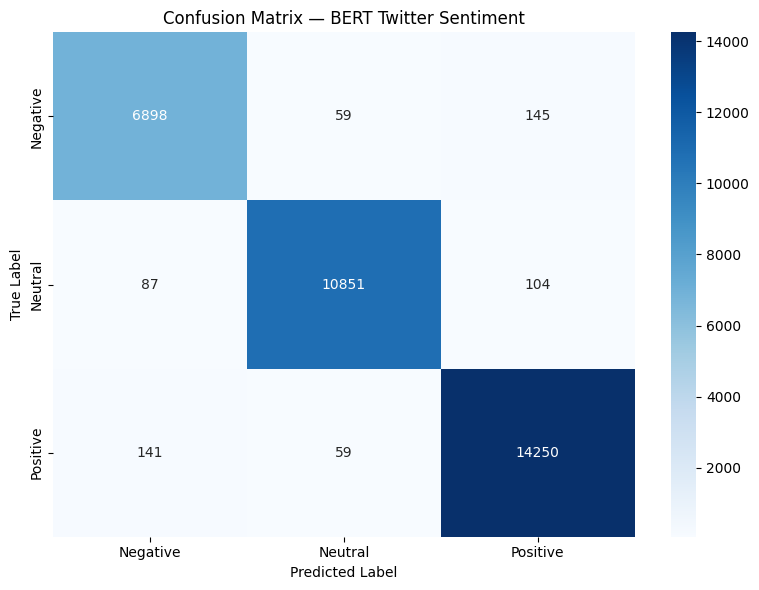

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Getting predictions"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        logits = model(input_ids, attention_mask)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)
plt.title("Confusion Matrix — BERT Twitter Sentiment")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

#Testing other tweets

In [ ]:
def predict_sentiment(text, model, tokenizer, device):
    model.eval()

    encoding = tokenizer(
        text,
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids      = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)

    probs      = torch.softmax(logits, dim=1).squeeze()
    pred_label = logits.argmax(dim=1).item()

    label_map = {0: "Negative 😞", 1: "Neutral 😐", 2: "Positive 😊"}

    return {
        "text":       text,
        "sentiment":  label_map[pred_label],
        "confidence": f"{probs[pred_label].item():.2%}"
    }


tweets = [
    "I absolutely love what he did for the country!",
    "The election results were announced today.",
    "This government has completely failed us.",
    "Just another day in politics, nothing new.",
    "Best decision ever made by the government!"
]

for tweet in tweets:
    result = predict_sentiment(tweet, model, tokenizer, device)
    print(f"[{result['sentiment']} | {result['confidence']}] {result['text']}")

[Positive 😊 | 99.98%] I absolutely love what he did for the country!
[Neutral 😐 | 99.97%] The election results were announced today.
[Negative 😞 | 99.95%] This government has completely failed us.
[Positive 😊 | 99.98%] Just another day in politics, nothing new.
[Positive 😊 | 99.98%] Best decision ever made by the government!


In [ ]:
from google.colab import drive

save_path = "/content/drive/MyDrive/Colab Notebooks/Twitter Sentiment Analysis - BERT"

torch.save(model.state_dict(), f"{save_path}/best_bert_sentiment.pt")
tokenizer.save_pretrained(f"{save_path}/tokenizer/")

print(f"✅ Model saved to {save_path}")

✅ Model saved to /content/drive/MyDrive/Colab Notebooks/Twitter Sentiment Analysis - BERT


In [ ]:

model = BertSentimentClassifier(num_classes=3)
model.load_state_dict(torch.load(f"{save_path}/best_bert_sentiment.pt"))
model.to(device)

tokenizer = BertTokenizer.from_pretrained(f"{save_path}/tokenizer/")

print("✅ Model loaded!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded!
